In [1]:
import tensorflow as tf
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import keras
from plot_keras_history import show_history, plot_history
import numpy as np
from keras import layers

In [2]:
def generate_regression_data():
    X, y = make_regression(n_samples=1000, n_features=5, n_informative=3, noise=15)
    
    y = y + 30 * np.sin(X[:, 0])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(X_train)
    x_test_scaled = scaler.transform(X_test)

    return x_train_scaled, x_test_scaled, y_train, y_test

In [3]:
def build_model(input_dim, hidden_layers: list, activation: list | str, type_of_cat):

    if isinstance(activation, str):
        activations = [activation] * len(hidden_layers)
    else:
        activations = activation
    
    model = Sequential()

    model.add(layers.Input(shape=(input_dim, )))
    
    for units, act in zip(hidden_layers, activations):
        model.add(layers.Dense(units, activation=act))
    if type_of_cat == "classification":
        model.add(layers.Dense(1, activation='sigmoid'))
    elif type_of_cat == "regression":
        model.add(layers.Dense(1))
    else:
        print("pick regression or classification")

    return model 

In [4]:
def train_model(model, X_train, y_train, epochs, type_of_cat, verbose = 0):

    if type_of_cat == "classification":
        model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy'])
            
    elif type_of_cat == "regression":
        model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='mse')
    else:
        print("pick regression or classification")
        
    history = model.fit(X_train, y_train, validation_split = 0.2, epochs= epochs)

    return history

In [5]:

def plot_history(history, cat_type: str = "classification", title: str = ""):
    if cat_type == "classification":
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Wykres Loss
        axes[0].plot(history.history['loss'], label='Trening (loss)', color='blue')
        axes[0].plot(history.history['val_loss'], label='Walidacja (val_loss)', color='red')
        axes[0].set_title(f"{title} - Loss")
        axes[0].set_xlabel('Epoki')
        axes[0].set_ylabel('Loss')
        axes[0].set_yscale('log')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.5)

        # Wykres Accuracy
        axes[1].plot(history.history['accuracy'], label='Trening (acc)', color='blue')
        axes[1].plot(history.history['val_accuracy'], label='Walidacja (val_acc)', color='red')
        axes[1].set_title(f"{title} - Accuracy")
        axes[1].set_xlabel('Epoki')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.5)

    elif cat_type == "regression":
        # Dla regresji generujemy pojedynczy, dopasowany wykres
        plt.figure(figsize=(8, 5))
        plt.plot(history.history['loss'], label='Trening (loss)', color='blue')
        plt.plot(history.history['val_loss'], label='Walidacja (val_loss)', color='red')
        plt.title(f"{title} - Loss (MSE)")
        plt.xlabel('Epoki')
        plt.ylabel('Loss')
        plt.yscale('log')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)

    else:
        raise ValueError(f"Nieznany typ: '{cat_type}'. Wybierz 'classification' lub 'regression'.")

    plt.tight_layout()
    plt.show()

In [6]:
X_train_scaled, X_test_scaled, y_train, y_test = generate_regression_data()

In [7]:
model = build_model(5, [16], 'relu', type_of_cat="regression")

In [8]:
history = train_model(model, X_train_scaled, y_train, epochs=200, type_of_cat="regression")

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12680.7832 - val_loss: 11631.7520
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12223.3682 - val_loss: 11067.9404
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11468.1348 - val_loss: 10073.7559
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10249.5166 - val_loss: 8725.3408
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8692.7051 - val_loss: 7077.1001
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6928.8076 - val_loss: 5303.1904
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5097.0610 - val_loss: 3675.2122
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3466.5813 - val_loss: 2298.9910
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2202.9666 - val_loss: 1295.1595
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1293.6721 - val_loss: 729.6761
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 805.2132 - val_loss: 43

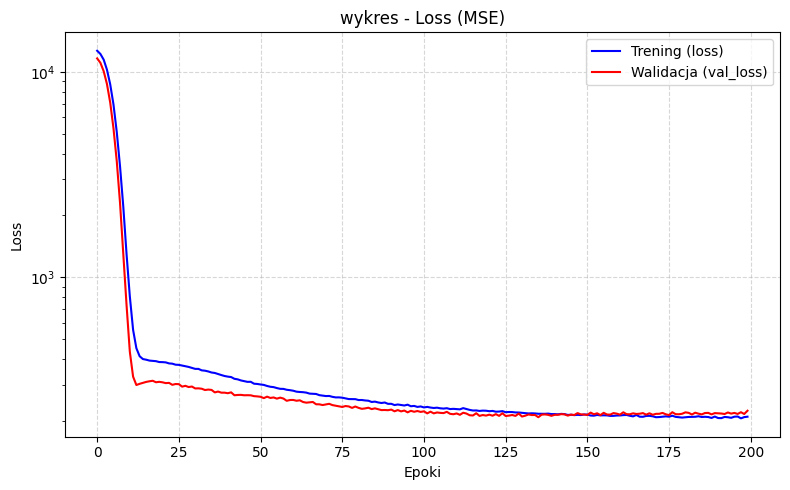

In [9]:
wykres = plot_history(history, "regression", "wykres")

In [61]:
# model dobrze sie uczy i generalizuje, na koncu widac maly rozjazd co moze oznaczac lekki overfiting,

# jak linie sie rozjezdaja to oznacza overfitting

In [60]:
# informacje 

loss (błąd treningowy) to wartość funkcji straty liczona na zbiorze treningowym. Optymalizator używa jej bezpośrednio do wyliczania gradientów i aktualizacji wag sieci po każdym batchu.

val_loss (błąd walidacyjny) to wartość funkcji straty mierzona na odłożonym zbiorze walidacyjnym, którego model nie używa do nauki. Wagi nigdy nie są modyfikowane na podstawie tych danych.

Kluczowe różnice

Cel: loss steruje optymalizacją modelu, a val_loss sprawdza jego zdolność do generalizacji (jak radzi sobie z nowymi danymi).
Moment pomiaru: loss to średnia krocząca liczona w trakcie trwania epoki, natomiast val_loss jest obliczany jednorazowo po zakończeniu całej epoki.

Diagnostyka stanu sieci:
Prawidłowy trening: obie wartości równolegle spadają.

Niedouczenie (underfitting): obie wartości zatrzymują się na wysokim poziomie.

Przeuczenie (overfitting): loss ciągle spada, a val_loss zaczyna rosnąć. Model zaczyna wkuwać dane treningowe na pamięć i traci zdolność generalizacji.

# zadanie 2

In [11]:
dict1 = {"no_hidden": [], "small": [8], "medium": [32], "two_layers": [64, 64], "large": [128, 128, 128]}

def compare_models(configs, data, epochs):

    histories = {}

    X_train_scaled, y_train = data

    for name, layers_num in configs.items():

        model= Sequential()
        model.add(layers.Input(shape=(5, )))
        
        for layer in layers_num:
    
            model.add(layers.Dense(layer, activation='relu'))

        model.add(layers.Dense(1))
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),loss='mse',metrics=['mae'])
        history = model.fit(X_train_scaled, y_train, validation_split = 0.2, verbose=0, epochs= epochs)
        histories[name] = history
        
    return histories

In [12]:
data_xy = (X_train_scaled, y_train)

In [13]:
models = compare_models(dict1, data_xy, epochs=150)

In [14]:
models

{'no_hidden': <keras.src.callbacks.history.History at 0x127b11950>,
 'small': <keras.src.callbacks.history.History at 0x127b12490>,
 'medium': <keras.src.callbacks.history.History at 0x1275056e0>,
 'two_layers': <keras.src.callbacks.history.History at 0x1275055b0>,
 'large': <keras.src.callbacks.history.History at 0x128054cb0>}

In [15]:
models['no_hidden'].history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [16]:
def to_df(models):
    data = []
    for name, history in models.items():
        mini_data = {"name" :name,
                     "mae" : history.history['mae'][-1],
                     "loss": history.history['loss'][-1],
                     "val_loss": history.history['val_loss'][-1]
                    }
        data.append(mini_data)
    
    df = pd.DataFrame(data)
    return df


In [17]:
df = to_df(models)
df

,name,mae,loss,val_loss
0,no_hidden,87.732224,11978.115234,11166.242188
1,small,34.880836,2316.153076,1982.436157
2,medium,15.691559,391.401550,308.769257
3,two_layers,11.006751,189.140244,241.751266
4,large,9.348118,139.639572,322.868530


In [66]:
for name, history in models.items():
    model = history.model
    loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"{name:<15} -> Test Loss: {loss:.2f}, Test MAE: {mae:.4f}")

no_hidden       -> Test Loss: 10726.70, Test MAE: 85.2488
small           -> Test Loss: 2061.09, Test MAE: 32.4008
medium          -> Test Loss: 386.82, Test MAE: 15.2653
two_layers      -> Test Loss: 263.27, Test MAE: 13.0355
large           -> Test Loss: 310.85, Test MAE: 13.9854


Luka między loss a val_loss (Generalization Gap):
Prawidłowy model: obie wartości są zbliżone (np. w medium 391 vs 308).   

Przeuczenie: duża różnica na korzyść zbioru treningowego (w large 139 vs 322).   

Kryterium wyboru modelu:

Nigdy nie wybierasz modelu po najniższym loss treningowym.
Szukasz minimum błędu na zbiorze testowym (Test MAE) lub walidacyjnym. Najniższy punkt osiągnął two_layers (13.0355).   

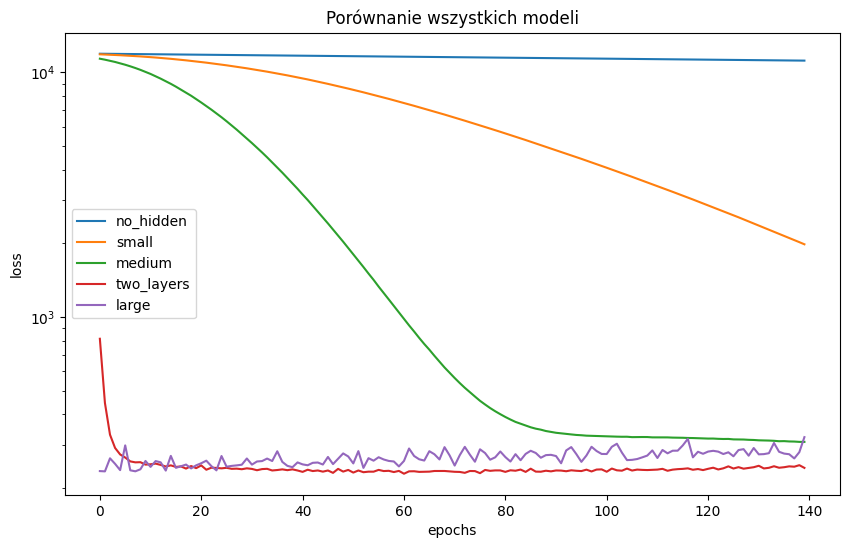

In [18]:
def plot_histories(histories):
    plt.figure(figsize=(10, 6))  

    for name, history in histories.items():  
        plt.plot(history.history['val_loss'][10:], label=name)

    plt.yscale('log')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title("Porównanie wszystkich modeli")
    plt.legend()
    plt.show() 

plot_histories(models)

In [68]:
# najgorzej wyszedl model bez warstw, a najlepiej model two layers. przeuczenia nie ma
# bez warstw nie moze dopasowac sie do nieliniowosci


# zadanie 3 

In [20]:
act_to_test = ['linear', 'sigmoid', 'tanh', 'relu', 'elu']

In [21]:
X_train_scaled_2, X_test_scaled_2, y_train_2, y_test_2 = generate_regression_data()

In [22]:
histories_2 = {}

for act in act_to_test:
    model = Sequential([
        layers.Input(shape=(5,)),
        layers.Dense(32, activation=act),
        layers.Dense(32, activation=act),
        layers.Dense(1)
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    histories_2[act] = model.fit(
        X_train_scaled_2, 
        y_train_2, 
        validation_split=0.2, 
        verbose=0, 
        epochs=100
    )
histories_2

{'linear': <keras.src.callbacks.history.History at 0x1683ace20>,
 'sigmoid': <keras.src.callbacks.history.History at 0x1683ae030>,
 'tanh': <keras.src.callbacks.history.History at 0x127bd6750>,
 'relu': <keras.src.callbacks.history.History at 0x127bd6150>,
 'elu': <keras.src.callbacks.history.History at 0x16891f2f0>}

In [23]:
histories_2['linear'].history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [24]:
df_2 = to_df(histories_2)
df_2

,name,mae,loss,val_loss
0,linear,12.893272,278.065369,291.243500
1,sigmoid,28.420872,1635.195312,1282.766846
2,tanh,20.205128,879.427124,663.085632
3,relu,12.229378,239.281342,284.194977
4,elu,12.120378,236.772949,274.276001


In [70]:
for name, history in histories_2.items():
    modelv2 = history.model
    loss, mae = modelv2.evaluate(X_test_scaled_2, y_test_2, verbose=0)
    print(f"{name:<15} -> Test Loss: {loss:.2f}, Test MAE: {mae:.4f}")

linear          -> Test Loss: 287.69, Test MAE: 13.6687
sigmoid         -> Test Loss: 1821.26, Test MAE: 32.0690
tanh            -> Test Loss: 961.05, Test MAE: 22.2000
relu            -> Test Loss: 282.93, Test MAE: 13.3339
elu             -> Test Loss: 271.72, Test MAE: 13.1259


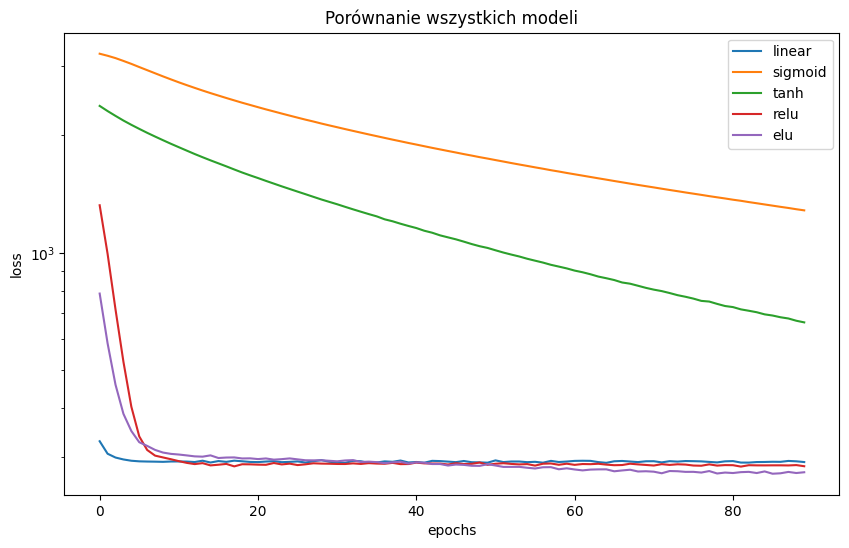

In [25]:
wykres_2 = plot_histories(histories_2)
wykres_2

# INFORMACJE

elu (Zwycięzca): MAE: 13.13, val_loss: 271.72. Gładka krzywa, brak problemu martwych neuronów dla wartości ujemnych, najniższy błąd w teście.   

relu: MAE: 13.33, val_loss: 282.93. Niemal identycznie skuteczna jak elu, uczy się błyskawicznie dzięki stałemu gradientowi równemu 1 dla wartości dodatnich.   

linear: MAE: 13.67, val_loss: 287.69. Zatrzymała się na poziomie błędu dopasowania liniowego; brak nieliniowości uniemożliwia lepszy wynik.   

tanh: MAE: 22.20, val_loss: 961.05. Uczy się stabilnie, ale wolno; potrzebuje znacznie więcej epok ze względu na spłaszczanie gradientu na krańcach.   

sigmoid (Najgorsza): MAE: 32.07, val_loss: 1821.26. Nie nadaje się do głębszych warstw ukrytych w MLP – maksymalna pochodna wynosi 0.25, przez co wsteczna propagacja drastycznie tłumi sygnał błędu.

In [26]:
for act, hist in histories_2.items():
    val_loss, mae = hist.model.evaluate(X_test_scaled_2, y_test_2, verbose=0)
    print(f"{act} mae: {mae}, val_loss: {val_loss}")

linear mae: 13.668719291687012, val_loss: 287.6940612792969
sigmoid mae: 32.06904602050781, val_loss: 1821.262939453125
tanh mae: 22.200044631958008, val_loss: 961.0499267578125
relu mae: 13.333944320678711, val_loss: 282.92987060546875
elu mae: 13.125898361206055, val_loss: 271.7156677246094


In [27]:
# model z aktywacja linear uczyl sie najszybciej - osiagnal limit w okolo 5 epoce

# zadanie 4 

In [28]:
from sklearn.datasets import make_classification, make_moons

def generate_classification_data(kind, random_state = 42):
    if kind == "blobs":
        X, y = make_classification(
        n_samples=1000, n_features=2, n_informative=2,
        n_redundant=0, n_clusters_per_class=2, flip_y=0.05, random_state=random_state)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    elif kind == "moons":
        X, y = make_moons(
        n_samples=1000, noise=0.2, random_state=random_state)

    else:
        raise ValueError("incorrect category")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

In [29]:
data_2 = generate_classification_data("blobs")
X_train_scaled_3, X_test_scaled_3, y_train_3, y_test_3 = data_2

In [30]:
data_3 = generate_classification_data("moons")
X_train_scaled_4, X_test_scaled_4, y_train_4, y_test_4 = data_3

In [31]:
def plot_decision_boundary(model, X, y, title: str = "Granica decyzyjna"):
    # 1. Wyznaczenie zakresu osi z marginesem
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # 2. Tworzenie gęstej siatki punktów (200x200)
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # 3. Predykcja dla całej siatki
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0)
    
    # Przekształcenie prawdopodobieństw na klasy 0/1 i format siatki
    preds = (preds > 0.5).astype(int).reshape(xx.shape)

    # 4. Rysowanie tła i rzeczywistych punktów
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=30)
    
    plt.title(title)
    plt.xlabel("Cecha 1 (X1)")
    plt.ylabel("Cecha 2 (X2)")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

In [32]:
# --- MOONS ---
m_moons_brak = build_model(2, [], 'relu', 'classification')
m_moons_maly = build_model(2, [8], 'relu', 'classification')
m_moons_gleb = build_model(2, [32, 32], 'relu', 'classification')

hist_moons_no = train_model(m_moons_brak, X_train_scaled_4, y_train_4, 100, 'classification')
hist_moons_one = train_model(m_moons_maly, X_train_scaled_4, y_train_4, 100, 'classification')
hist_moons_two = train_model(m_moons_gleb, X_train_scaled_4, y_train_4, 100, 'classification')

# --- BLOBS ---
m_blobs_brak = build_model(2, [], 'relu', 'classification')
m_blobs_maly = build_model(2, [8], 'relu', 'classification')
m_blobs_gleb = build_model(2, [32, 32], 'relu', 'classification')

hist_blobs_no = train_model(m_blobs_brak, X_train_scaled_3, y_train_3, 100, 'classification')
hist_blobs_one = train_model(m_blobs_maly, X_train_scaled_3, y_train_3, 100, 'classification')
hist_blobs_two = train_model(m_blobs_gleb, X_train_scaled_3, y_train_3, 100, 'classification')

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4172 - loss: 0.8011 - val_accuracy: 0.4437 - val_loss: 0.7740
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5078 - loss: 0.7045 - val_accuracy: 0.4875 - val_loss: 0.6887
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5531 - loss: 0.6308 - val_accuracy: 0.5750 - val_loss: 0.6228
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6062 - loss: 0.5746 - val_accuracy: 0.6313 - val_loss: 0.5729
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6531 - loss: 0.5317 - val_accuracy: 0.6812 - val_loss: 0.5312
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6812 - loss: 0.4948 - val_accuracy: 0.7125 - val_loss: 0.4985
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7156 - loss: 0.4668 - val_accuracy: 0.7312 - val_loss: 0.4691
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7375 - loss: 0.4417 - val_accuracy: 0.7500 - v

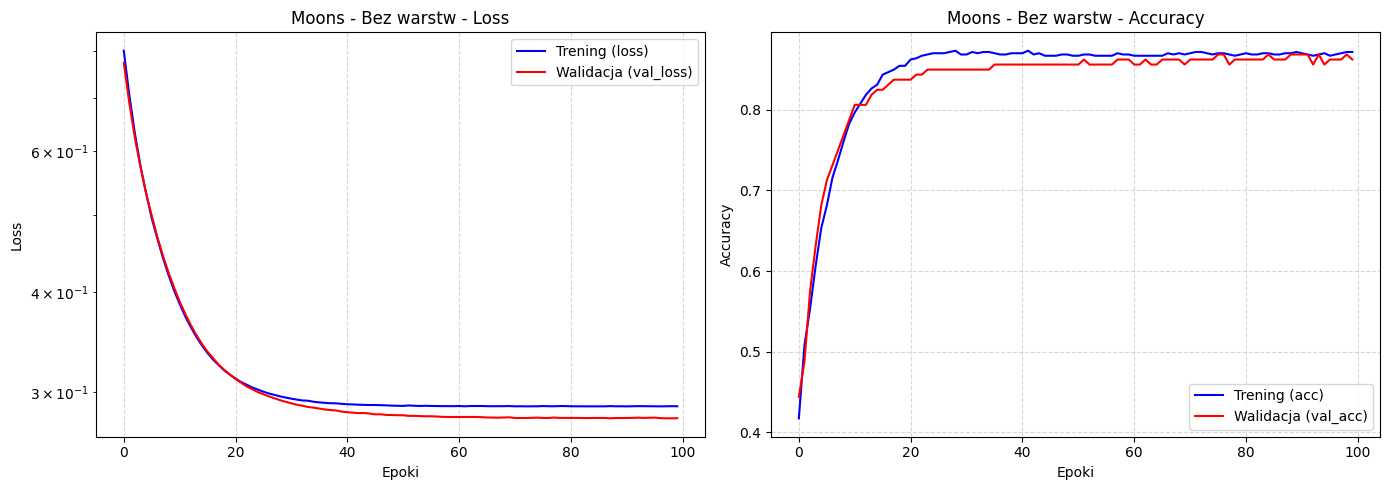

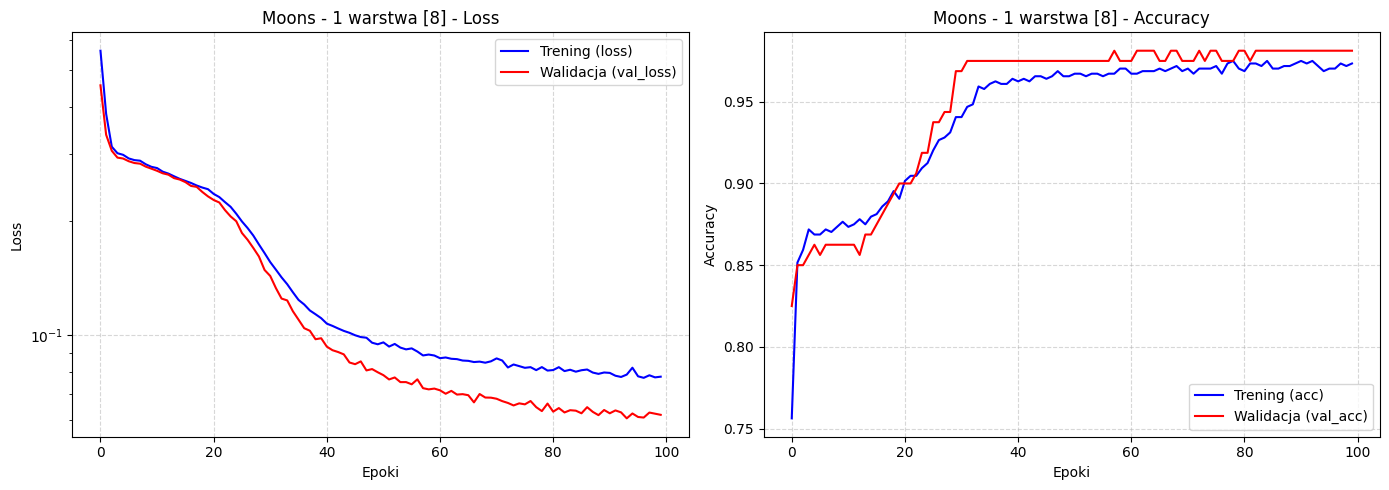

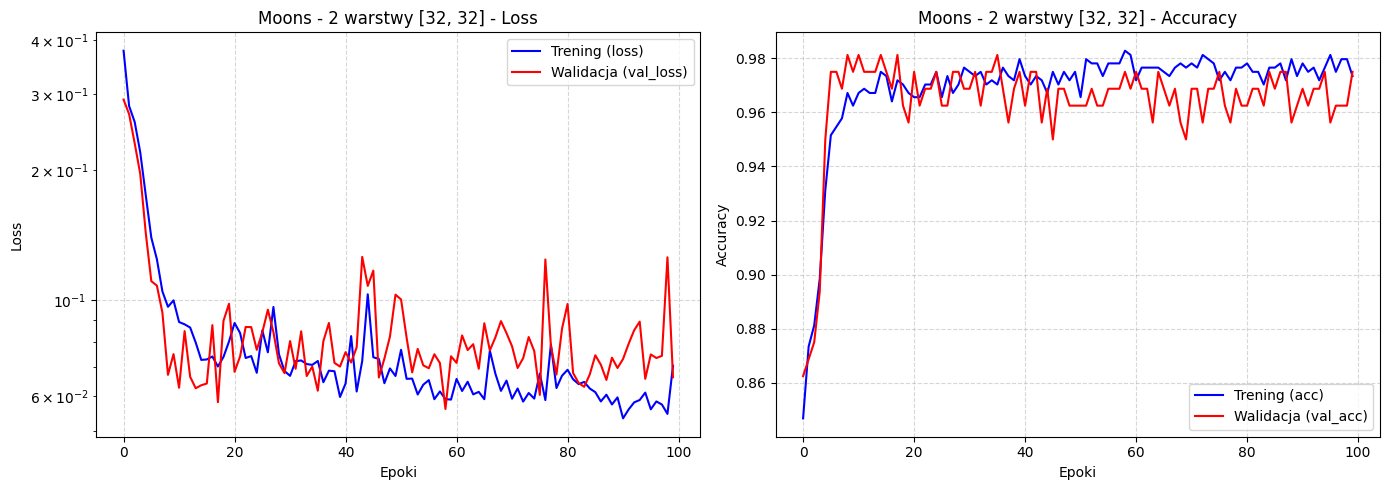

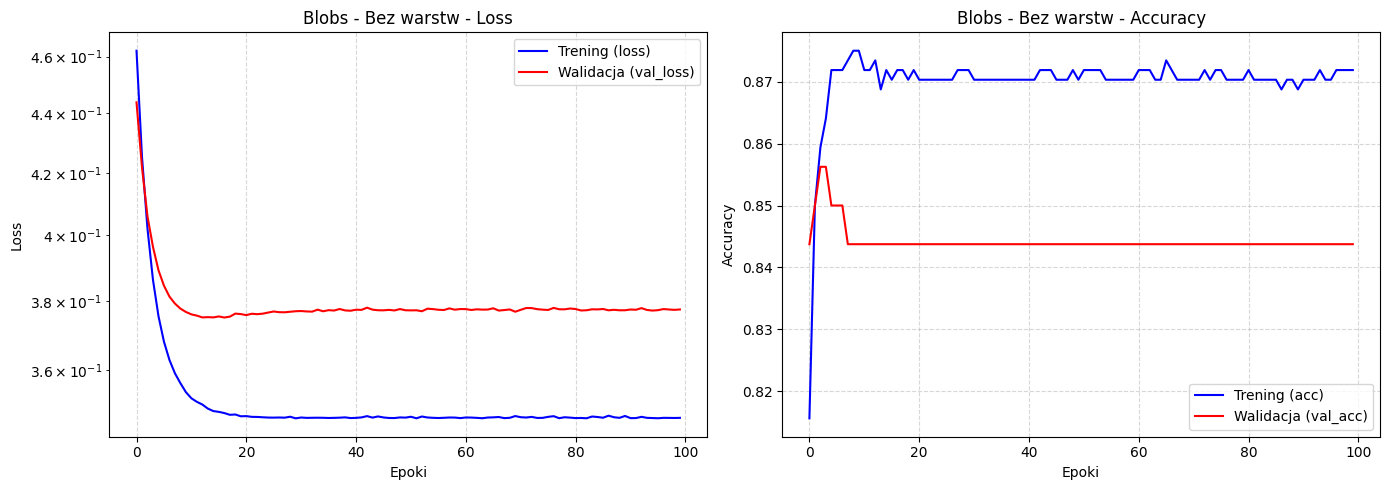

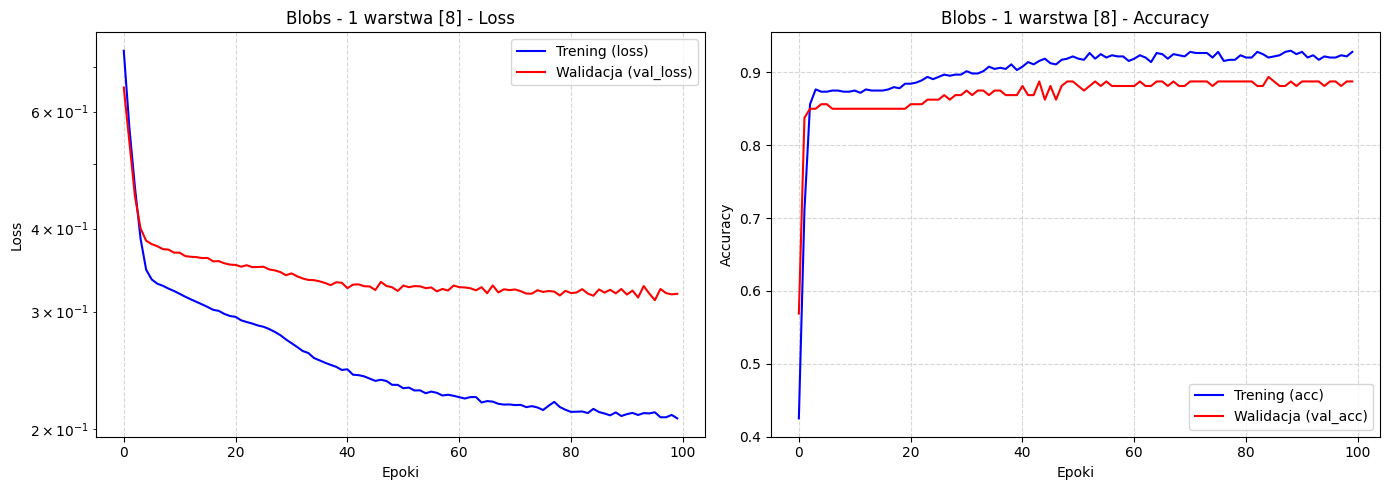

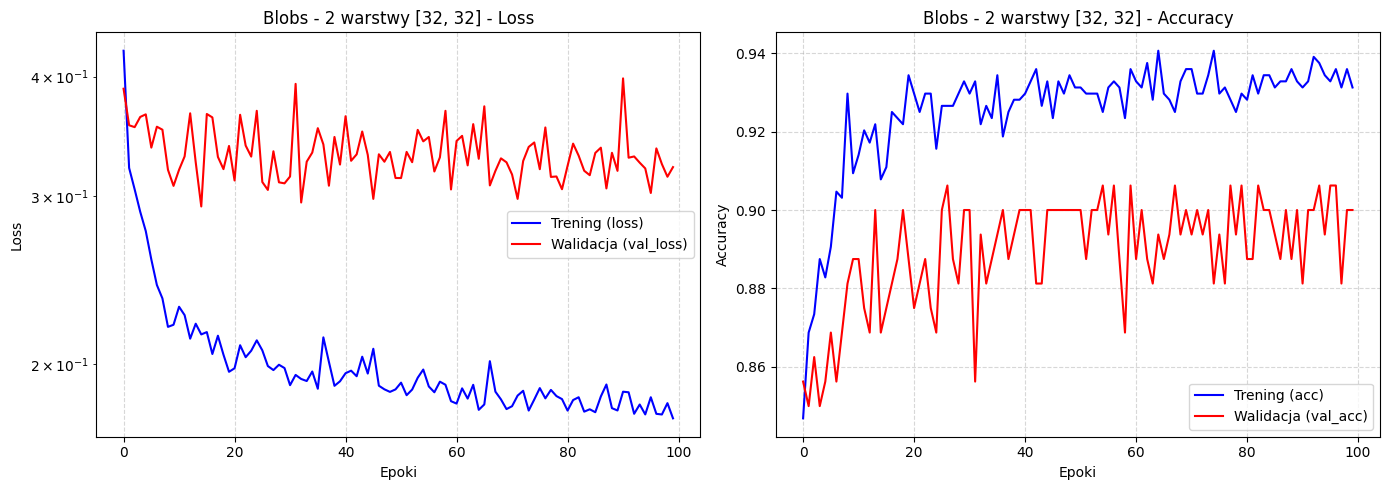

In [33]:
histories = {
    "Moons - Bez warstw": hist_moons_no,
    "Moons - 1 warstwa [8]": hist_moons_one,
    "Moons - 2 warstwy [32, 32]": hist_moons_two,
    "Blobs - Bez warstw": hist_blobs_no,
    "Blobs - 1 warstwa [8]": hist_blobs_one,
    "Blobs - 2 warstwy [32, 32]": hist_blobs_two,
}

for title, hist in histories.items():
    plot_history(hist, title=title)

In [74]:
# modele nie osiagna 100 % skutecznosci poniewaz jest dodane 5 procent szumu
# niektore modele na sile robia "wyspy" zeby zgadnac 5 procent szumu
# model liniowy bez warstw nie porawdzi sobie z moons bo jest prosta linia a dane sa pierscieniami

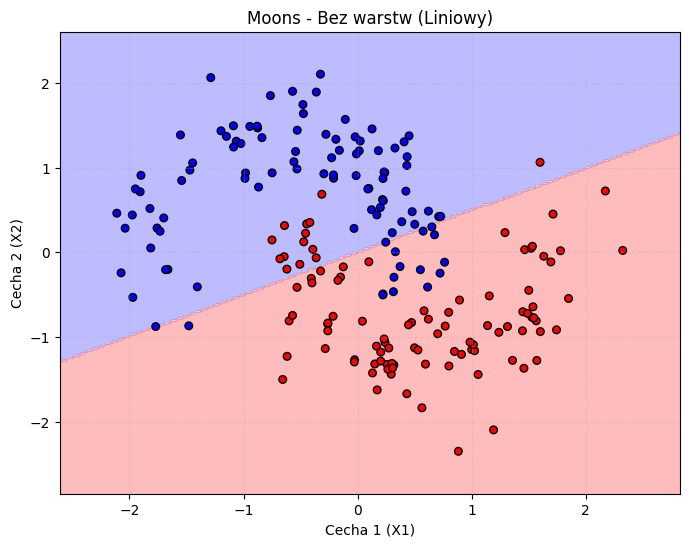

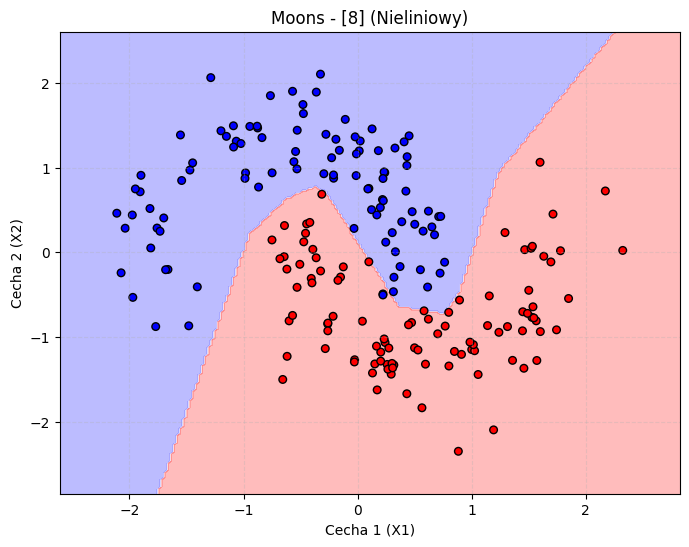

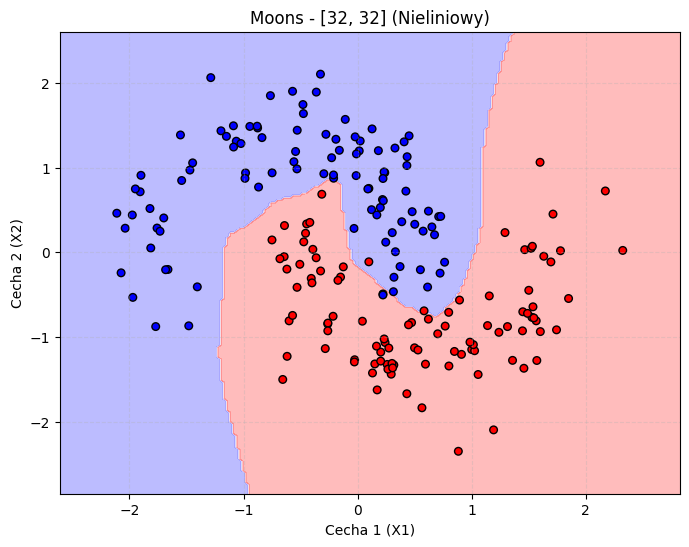

In [75]:
plot_decision_boundary(m_moons_brak, X_test_scaled_4, y_test_4, title="Moons - Bez warstw (Liniowy)")

plot_decision_boundary(m_moons_maly, X_test_scaled_4, y_test_4, title="Moons - [8] (Nieliniowy)")
plot_decision_boundary(m_moons_gleb, X_test_scaled_4, y_test_4, title="Moons - [32, 32] (Nieliniowy)")

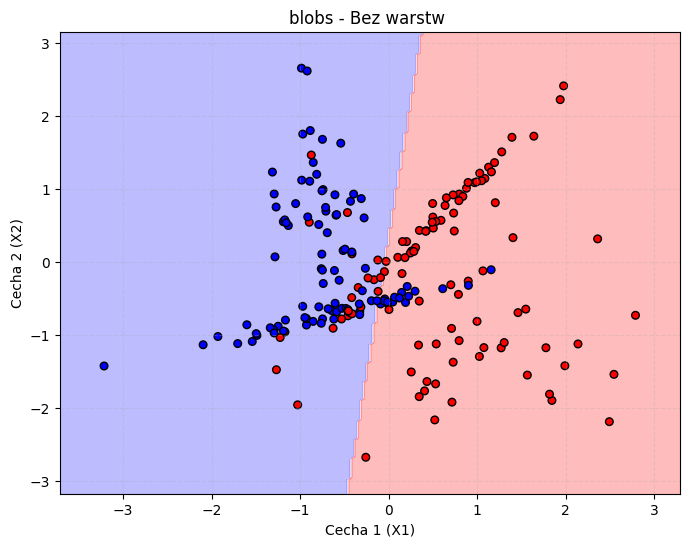

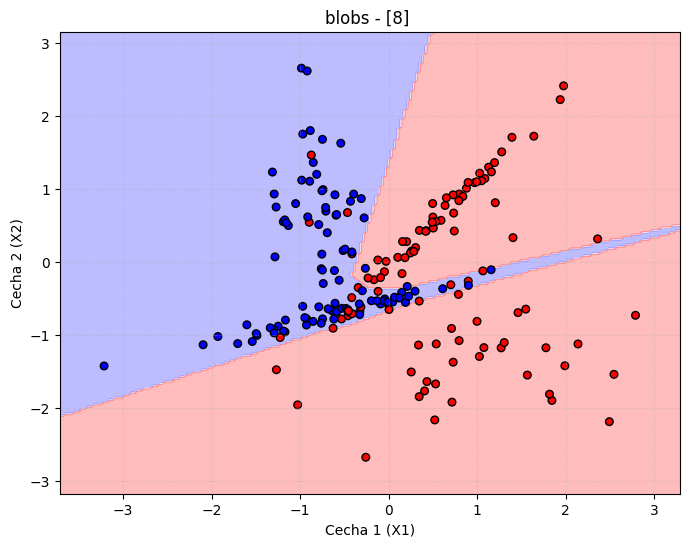

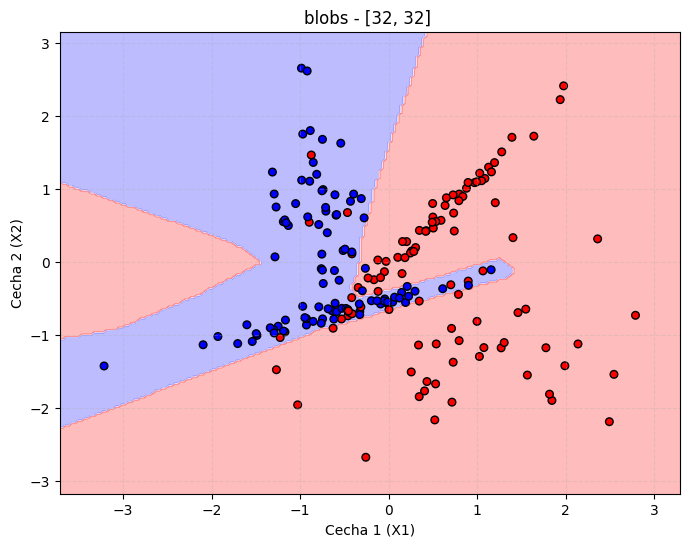

In [36]:
plot_decision_boundary(m_blobs_brak, X_test_scaled_3, y_test_3, title="blobs - Bez warstw ")

plot_decision_boundary(m_blobs_maly, X_test_scaled_3, y_test_3, title="blobs - [8] ")
plot_decision_boundary(m_blobs_gleb, X_test_scaled_3, y_test_3, title="blobs - [32, 32] ")

# zadanie 5

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
X_5, y_5 = make_classification(n_samples=3000, n_features=10, n_informative=5, n_classes=4, class_sep=1.0)

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_5, y_5, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled_5 = scaler.fit_transform(X_train_5)
X_test_scaled_5 = scaler.transform(X_test_5)

In [39]:
model_5 = Sequential([
    layers.Input(shape = (10,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')])


model_5.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.01),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',        # metryka do obserwacji
    patience=10,               # ile epok bez poprawy czekamy przed przerwaniem
    restore_best_weights=True  # cofa wagi do najlepszej epoki 
)

history_5 = model_5.fit(
        X_train_scaled_5, 
        y_train_5, 
        validation_split=0.2, 
        verbose=0, 
        callbacks=[early_stop],
        epochs=300
    )
history_5

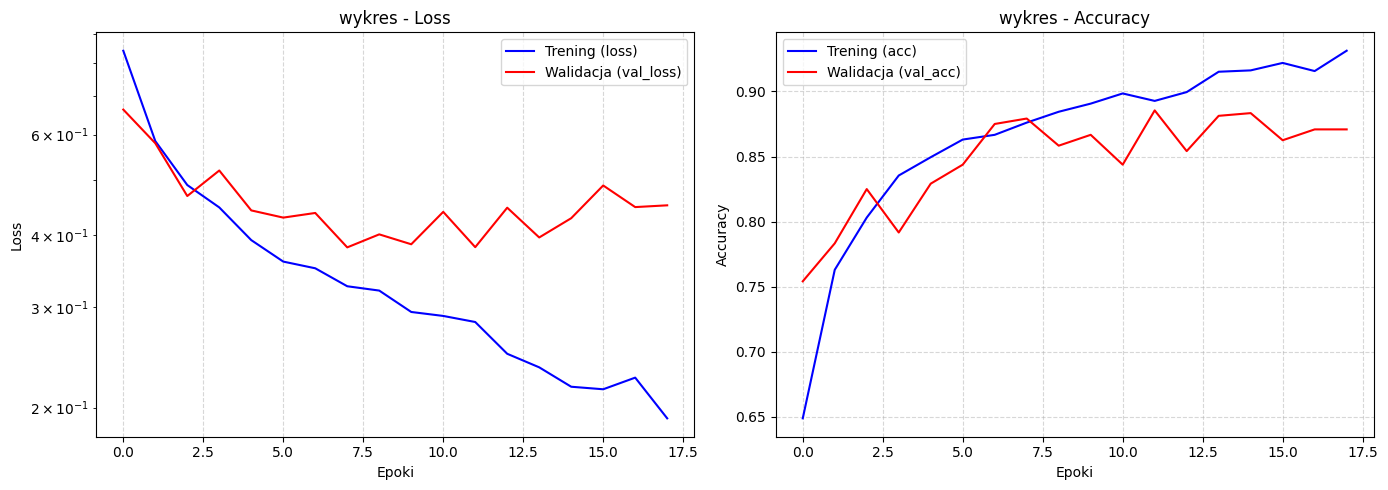

In [40]:
plot_history(history_5, cat_type = "classification", title = "wykres")

In [41]:
len(history_5.history['loss'])

18

In [42]:
model_6 = Sequential([
    layers.Input(shape = (10,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')])


model_6.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.01),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])

history_6 = model_6.fit(
        X_train_scaled_5, 
        y_train_5, 
        validation_split=0.2, 
        verbose=0, 
        epochs=300
    )
history_6

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

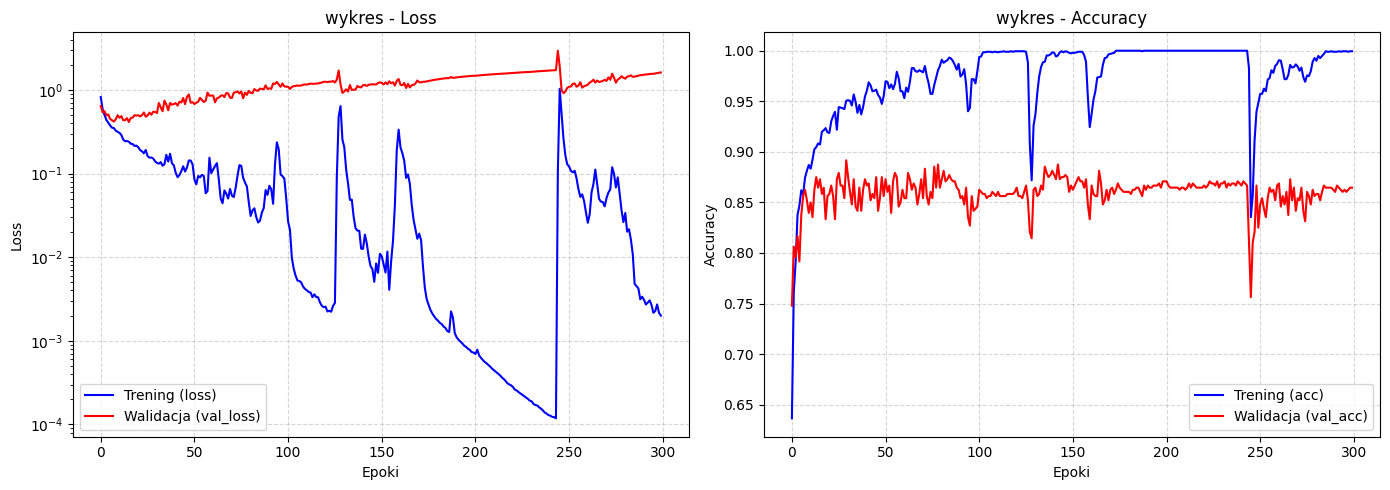

In [44]:
plot_history(history_6, cat_type = "classification", title = "wykres")

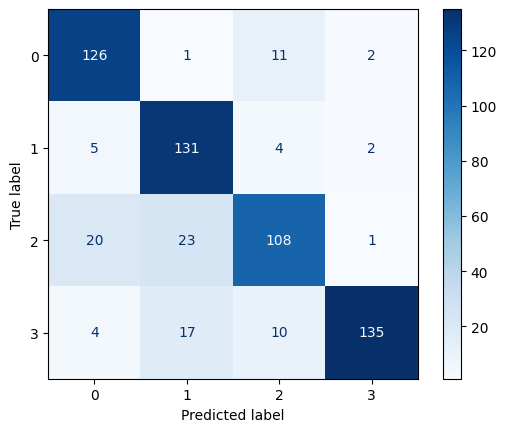

0.8333333333333334

In [45]:
def evaluate_classifier(model, X_test, y_test):
    
    y_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_probs, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.show()

    return acc
model_5_acc = evaluate_classifier(model_5, X_test_scaled_5, y_test_5)
model_5_acc

Early Stopping: Przerywa trening automatycznie w momencie, gdy model przestaje robić postępy na danych walidacyjnych (val_loss), zapobiegając przeuczeniu (overfitting) i marnowaniu czasu.

Parametr patience (bufor cierpliwości): To nie „długość przeuczenia”, lecz liczba kolejnych epok bez poprawy rekordu, jakie dajesz modelowi, zanim trening zostanie przerwany.

In [46]:
# model najczesciej myli klase 1 z klasa 2 

# zadanie 6

In [47]:
def run_experiment(X_train, y_train, depths, widths, activations):
    
    histories = {}


    for dep in depths:
            for wid in widths:
                for act in activations:
                    model = Sequential([
                    layers.Input(shape=(10,))
                    ])
                    for _ in range(dep):
                        model.add(layers.Dense(wid, activation = act))
                    model.add(layers.Dense(4, activation='softmax'))

                    model.compile(
                    optimizer = keras.optimizers.Adam(learning_rate=0.01),
                    loss = 'sparse_categorical_crossentropy',
                    metrics = ['accuracy'])
                
                    early_stop = EarlyStopping(
                    monitor='val_loss',        # metryka do obserwacji
                    patience=10,               # ile epok bez poprawy czekamy przed przerwaniem
                    restore_best_weights=True  # cofa wagi do najlepszej epoki 
                )

                    history = model.fit(
                    X_train, 
                    y_train, 
                    validation_split=0.2, 
                    verbose=0, 
                    epochs=300,
                    callbacks = [early_stop]
                )

                    histories[f"d{dep}_w{wid}_{act}"] = history

    return histories 

hist = run_experiment(X_train_scaled_5, y_train_5, [1, 2], [16, 64], ['relu', 'tanh'])

In [48]:
hist

{'d1_w16_relu': <keras.src.callbacks.history.History at 0x175a11c70>,
 'd1_w16_tanh': <keras.src.callbacks.history.History at 0x175906170>,
 'd1_w64_relu': <keras.src.callbacks.history.History at 0x1758569f0>,
 'd1_w64_tanh': <keras.src.callbacks.history.History at 0x17937b250>,
 'd2_w16_relu': <keras.src.callbacks.history.History at 0x1793b4450>,
 'd2_w16_tanh': <keras.src.callbacks.history.History at 0x169c09010>,
 'd2_w64_relu': <keras.src.callbacks.history.History at 0x169a7cc20>,
 'd2_w64_tanh': <keras.src.callbacks.history.History at 0x179879a20>}

In [49]:
def to_df_v2(models):
    data = []
    for name, history in models.items():
        mini_data = {"name" :name,
                     "loss": history.history['loss'][-1],
                     "val_loss": history.history['val_loss'][-1],
                     "val_acc": history.history['val_accuracy'][-1]
                    }
        data.append(mini_data)
    
    df = pd.DataFrame(data)
    return df

In [50]:
df2 = to_df_v2(hist)
df2

,name,loss,val_loss,val_acc
0,d1_w16_relu,0.407085,0.457776,0.845833
1,d1_w16_tanh,0.279157,0.379389,0.866667
2,d1_w64_relu,0.205842,0.410174,0.875000
3,d1_w64_tanh,0.159344,0.410736,0.887500
4,d2_w16_relu,0.265017,0.479661,0.875000
5,d2_w16_tanh,0.254216,0.370206,0.875000
6,d2_w64_relu,0.153116,0.529937,0.860417
7,d2_w64_tanh,0.075059,0.421738,0.889583


In [51]:
hist['d1_w16_relu'].history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [52]:
test_results = []

for name, h in hist.items():
    loss, acc = h.model.evaluate(X_test_scaled_5, y_test_5, verbose=0)
    test_results.append({
        "Konfiguracja": name,
        "Liczba parametrów": h.model.count_params(),     
        "Liczba epok": len(h.history['loss']),
        "Dokładność testowa": round(acc, 4)
    })

df_3 = pd.DataFrame(test_results)
df_3 = df_3.sort_values(by= 'Dokładność testowa', ascending = False).reset_index(drop=True)

df_3

,Konfiguracja,Liczba parametrów,Liczba epok,Dokładność testowa
0,d1_w16_tanh,244,74,0.8617
1,d2_w64_tanh,5124,27,0.8617
2,d2_w16_tanh,516,25,0.8600
3,d2_w64_relu,5124,23,0.8567
4,d1_w64_relu,964,36,0.8550
5,d1_w64_tanh,964,38,0.8450
6,d2_w16_relu,516,36,0.8317
7,d1_w16_relu,244,56,0.8133


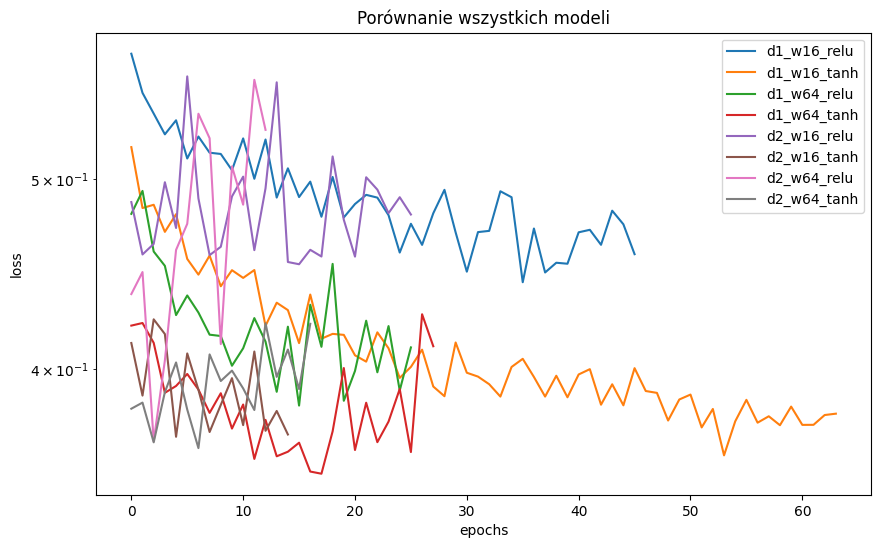

In [53]:
plots = plot_histories(hist)

In [54]:
top_keys = ['d2_w64_tanh', 'd1_w64_relu', 'd2_w16_tanh']

top_3_hist = {k: hist[k] for k in top_keys}
top_3_hist

{'d2_w64_tanh': <keras.src.callbacks.history.History at 0x179879a20>,
 'd1_w64_relu': <keras.src.callbacks.history.History at 0x1758569f0>,
 'd2_w16_tanh': <keras.src.callbacks.history.History at 0x169c09010>}

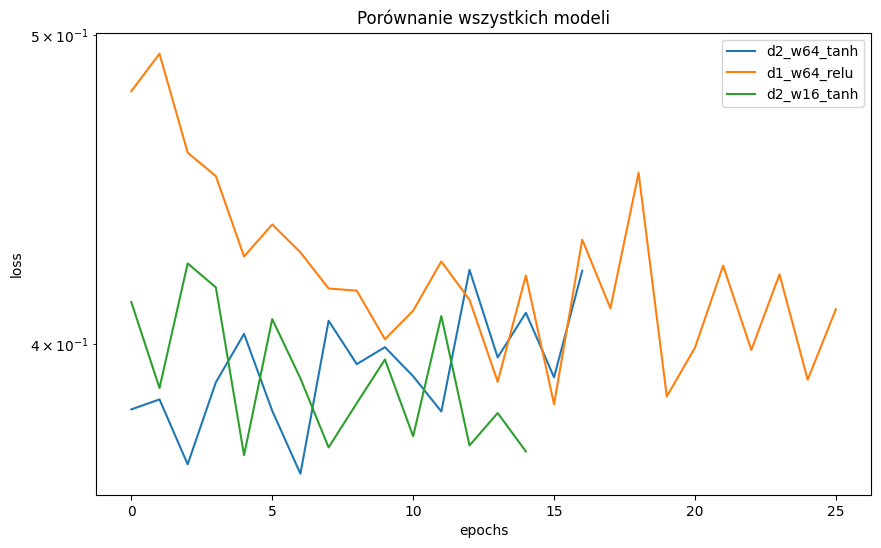

In [55]:
plots = plot_histories(top_3_hist)

In [56]:
best_model = hist['d2_w64_tanh'].model
best_model

<Sequential name=sequential_26, built=True>

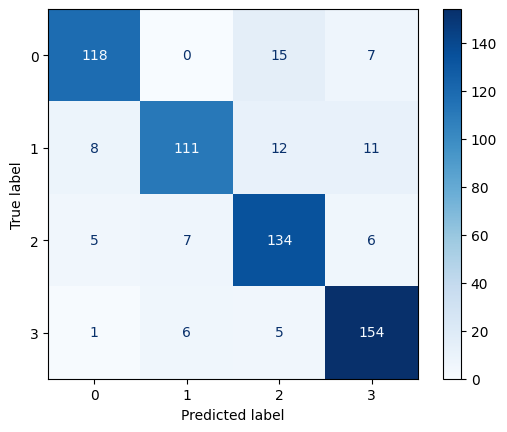

0.8616666666666667

In [57]:
b_model = evaluate_classifier(best_model, X_test_scaled_5, y_test_5)
b_model

In [58]:
df_3

,Konfiguracja,Liczba parametrów,Liczba epok,Dokładność testowa
0,d1_w16_tanh,244,74,0.8617
1,d2_w64_tanh,5124,27,0.8617
2,d2_w16_tanh,516,25,0.8600
3,d2_w64_relu,5124,23,0.8567
4,d1_w64_relu,964,36,0.8550
5,d1_w64_tanh,964,38,0.8450
6,d2_w16_relu,516,36,0.8317
7,d1_w16_relu,244,56,0.8133


In [77]:
# zwiekszenie wag w aktywacji tahn nic nie dalo bo 244 parametrow zadzialalo tak samo jak 5124, najwieksze znaczenie miala funkcja aktywacji